# Periodogram of a kinetic-energy time series

Interactive companion to [`periodogram_KineticEnergy.py`](periodogram_KineticEnergy.py).

It reads a per-run `KineticEnergy_timeSeries.npz` (produced by
`batch_KineticEnergy.py`, containing `t`, `Ek_frame` and the PIV sampling
frequency `fps`), computes the **periodogram** (power spectral density estimate)
of `Ek(t)` with `scipy.signal.periodogram`, and draws two panels:

1. the kinetic-energy time series `Ek(t)`;
2. its periodogram versus frequency.

The periodogram uses a one-sided, power-conserving PSD scaling. The default
`boxcar` window gives the classical periodogram; pick another window (e.g.
`hann`) to trade frequency resolution for reduced spectral leakage. By default
the mean is removed first so the DC term does not dwarf the rest. If the
libration frequency can be parsed from the run name, dashed guides are drawn at
`flib` and `2*flib`.

## 1. Imports

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

%matplotlib widget

NPZ_NAME = "KineticEnergy_timeSeries.npz"
FLIB_DIVISOR = 1000.0   # folder token 'flib0400' -> 0.400 Hz (matches batch)

## 2. Configuration

Edit these, then run the cells below. `PATH` may be the `.npz` file itself or a
run folder (its `PostProcessing/KineticEnergy_timeSeries.npz` is used).

In [2]:
# --- edit me -------------------------------------------------------------
PATH    = "/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib1500_dphi3deg_SS1/PostProcessing"   # run folder or .npz
DETREND = True        # remove the mean before the estimate (kills the DC spike)
WINDOW  = "boxcar"    # scipy window; 'boxcar' = classical periodogram, try 'hann'
LOGY    = True        # logarithmic power axis (False -> linear)
SAVE    = False       # also write a PNG next to the .npz
OUTPUT  = None        # PNG path; None -> KineticEnergy_Periodogram.png beside the .npz
# -------------------------------------------------------------------------

## 3. Helper functions

Same logic as the script.

In [3]:
def resolve_npz(path):
    """Accept the .npz path directly or a run folder containing it."""
    if os.path.isdir(path):
        cand = os.path.join(path, "PostProcessing", NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        cand = os.path.join(path, NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        raise FileNotFoundError("No %s under %s" % (NPZ_NAME, path))
    if os.path.isfile(path):
        return path
    raise FileNotFoundError(path)


def parse_flib(run_name):
    """Libration frequency (Hz) from a run name, or None."""
    m = re.search(r"flib(\d+)", str(run_name))
    return float(m.group(1)) / FLIB_DIVISOR if m else None


def compute_periodogram(ek, fps, detrend=True, window="boxcar"):
    """Return (freq, pxx) for the one-sided periodogram of Ek(t).

    Thin wrapper around scipy.signal.periodogram: it computes the power
    spectral density estimate P(f) with the given window (default 'boxcar',
    i.e. the classical periodogram) and a one-sided scaling that conserves
    total power. Units are (Ek units)^2 / Hz.
    """
    ek = np.asarray(ek, dtype=float)
    # Fill any NaNs (e.g. fully-masked frames) with the series mean.
    if np.any(np.isnan(ek)):
        ek = np.where(np.isnan(ek), np.nanmean(ek), ek)
    freq, pxx = periodogram(
        ek, fs=fps, window=window,
        detrend=("constant" if detrend else False),
        scaling="density", return_onesided=True)
    return freq, pxx

## 4. Load the time series

In [4]:
npz_path = resolve_npz(PATH)
print("Reading %s" % npz_path)

data = np.load(npz_path, allow_pickle=True)
t = data["t"]
ek = data["Ek_frame"]
fps = float(data["fps"]) if "fps" in data.files else 1.0
run = str(data["run"]) if "run" in data.files else os.path.basename(
    os.path.dirname(npz_path))

flib = parse_flib(run)
print("run  = %s" % run)
print("fps  = %g Hz   nframes = %d" % (fps, ek.size))
print("flib = %s" % ("%g Hz" % flib if flib else "unknown"))

Reading /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib1500_dphi3deg_SS1/PostProcessing/KineticEnergy_timeSeries.npz
run  = frot050_flib1500_dphi3deg_SS1
fps  = 25 Hz   nframes = 1500
flib = 1.5 Hz


## 5. Compute the periodogram

In [5]:
freq, pxx = compute_periodogram(ek, fps, detrend=DETREND, window=WINDOW)

# Peak frequency (ignoring the DC bin).
if pxx.size > 1:
    k = 1 + int(np.argmax(pxx[1:]))
    print("peak at %.4f Hz  (PSD = %.3e)" % (freq[k], pxx[k]))
    if flib:
        print("  flib = %.4f Hz, 2*flib = %.4f Hz" % (flib, 2 * flib))

peak at 0.1500 Hz  (PSD = 1.297e-13)
  flib = 1.5000 Hz, 2*flib = 3.0000 Hz


## 6. Plot

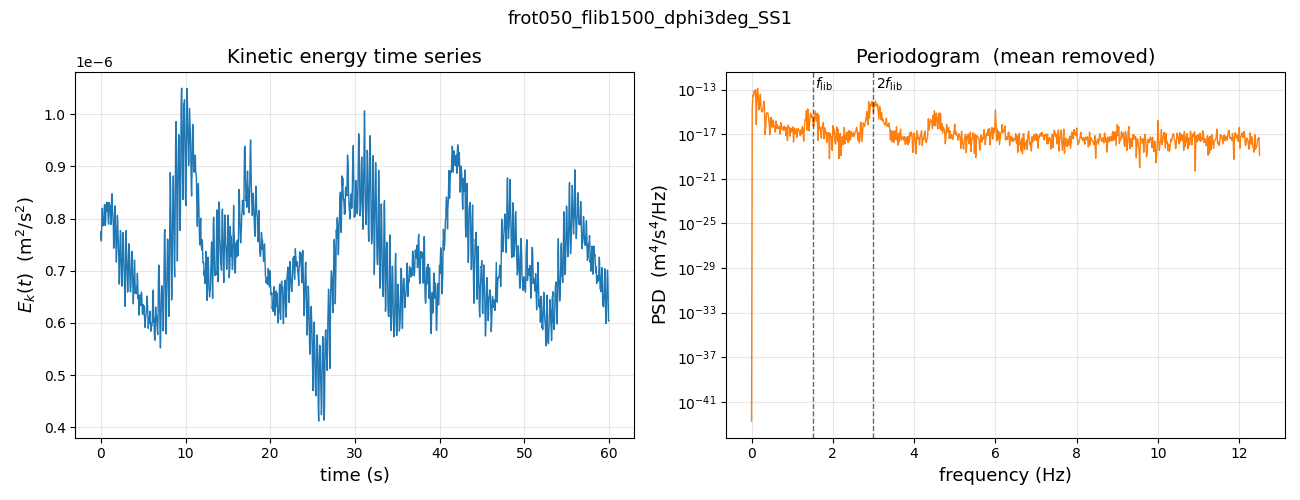

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: time series
axes[0].plot(t, ek, color="C0", lw=1)
axes[0].set_xlabel("time (s)", fontsize=13)
axes[0].set_ylabel(r"$E_k(t)$  (m$^2$/s$^2$)", fontsize=13)
axes[0].set_title("Kinetic energy time series", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Panel 2: periodogram
if LOGY:
    axes[1].semilogy(freq, pxx, color="C1", lw=1)
else:
    axes[1].plot(freq, pxx, color="C1", lw=1)
axes[1].set_xlabel("frequency (Hz)", fontsize=13)
axes[1].set_ylabel(r"PSD  (m$^4$/s$^4$/Hz)", fontsize=13)
ttl = "Periodogram" + ("  (mean removed)" if DETREND else "")
axes[1].set_title(ttl, fontsize=14)
axes[1].grid(True, alpha=0.3, which="both")
if flib:
    for f, lbl in ((flib, r"$f_{\mathrm{lib}}$"),
                   (2 * flib, r"$2f_{\mathrm{lib}}$")):
        if f <= freq.max():
            axes[1].axvline(f, color="k", ls="--", lw=1, alpha=0.6)
            axes[1].annotate(lbl, xy=(f, 1), xycoords=("data", "axes fraction"),
                             xytext=(2, -12), textcoords="offset points",
                             fontsize=10)

fig.suptitle(run, fontsize=13)
fig.tight_layout()

if SAVE:
    output = OUTPUT or os.path.join(
        os.path.dirname(npz_path), "KineticEnergy_Periodogram.png")
    fig.savefig(output, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % output)

plt.show()

In [7]:
1/((48.6-42)/1)


0.1515151515151515